In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web

td.config.logging_level = "ERROR"

import autograd.numpy as anp
import autograd

In [2]:
a = 1.0 # lattice cell units

freqs = td.C_0 / a * np.linspace(0.29, 0.42)
freq0 = np.mean(freqs)

wvls = td.C_0 / freqs
wvl0 = td.C_0 / freq0

fwidth = freq0 / 20
run_time = 200 / fwidth

In [3]:
n_si = 3.4  # silicon refractive index
si = td.Medium(permittivity=n_si**2)

n_air = 1  # air refractive index
air = td.Medium(permittivity=n_air)


In [4]:
r0 = 0.2 * a  # radius of air holes

r_range = (0.5 * r0, 1.5 * r0)

N_rows = 11  # number of pillars in a row (x)
N_cols = 11  # number of pillars in a column (y)

n_cells_pml = 5

Lx_phc = N_cols * a
Ly_phc = N_rows * a


buffer = 2 * wvl0

In [5]:
# position of pillar in the (-x, -y) quadrant
x_min = -Lx_phc / 2 + a/2
y_min = -Ly_phc / 2 + a/2 - n_cells_pml * a

# size of simulation
Lx = Lx_phc + buffer
Ly = Ly_phc

In [6]:
def get_radii(params):
    """Radius of each PhC pillar between 0 and a as a function of params (-inf, +inf)."""
    rad_01 = 0.5 * (anp.tanh(params) + 1.0)
    rmin, rmax = r_range
    return rmin + (rmax - rmin) * rad_01

In [7]:
def make_pillars(params, is_bent: bool) -> list[td.Structure]:

    rs = get_radii(params)
    
    pillars = []
    
    for i in range(N_rows + n_cells_pml):
        for j in range(N_cols + 2 * n_cells_pml):

            ip = i
            jp = j - n_cells_pml

            if jp >=0  and jp < N_cols and ip < N_rows:
                r = rs[ip, jp]
            else:
                r = r0

            
            
            x0 = x_min + a * i
            y0 = y_min + a * j
            geo = td.Cylinder(
                center=(x0, y0, 0),
                length=td.inf,
                radius=r,
                axis=2
            )
            structure = td.Structure(
                geometry=geo,
                medium=si,
            )

            i_center = N_cols // 2 
            j_center = N_rows // 2 + n_cells_pml
            
            # if is_bent:   
            #     if j == j_center and i <= i_center:
            #         continue
            #     if j <= j_center and i == i_center:
            #         continue
            # else:
            if j == j_center:
                continue

            pillars.append(structure)                    

    return pillars

In [8]:
source = td.PlaneWave(
    center=(-Lx/2 + wvl0/10, 0, 0),
    size=(0, Ly_phc/2.0, td.inf),
    direction="+",
    source_time=td.GaussianPulse(
        freq0=freq0,
        fwidth=fwidth
    ),
    pol_angle=np.pi/2, # TM
)

In [9]:
mnt_flux_x = td.FluxMonitor(
    center=(+Lx_phc/2 - a, 0, 0),
    size=(0, Ly_phc/2, td.inf),
    freqs=freqs,
    name='flux_x',
)

mnt_flux_y = td.FluxMonitor(
    center=(0, -Ly/2 + a, 0),
    size=(Lx_phc/2, 0, td.inf),
    freqs=freqs,
    name='flux_y',
)

mnt_field_x = td.FieldMonitor(
    center=(+Lx_phc/2 - a, 0, 0),
    size=(0, Ly_phc/2, td.inf),
    freqs=[freq0],
    name='flux_x',
)

mnt_field_y = td.FieldMonitor(
    center=(0, -Ly/2 + a, 0),
    size=(Lx_phc/2, 0, td.inf),
    freqs=[freq0],
    name='flux_y',
)

mnt_field = td.FieldMonitor(
    center=(0, 0, 0),
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name='field',
)


In [10]:
# define grids
steps_per_unit_cell = 20
dl = a / steps_per_unit_cell

grid_spec = td.GridSpec.uniform(dl=dl)

In [11]:
def make_sim(params, is_bent: bool, optimization_mode: bool = False) -> td.Simulation:

    
    if not optimization_mode:
        monitors = [mnt_flux_x, mnt_flux_y]
        monitors += [mnt_field]
    else:
        monitors = [mnt_field_x, mnt_field_y]
    
    pillars = make_pillars(params, is_bent=is_bent)

    num_layers_pml = max(40, a * n_cells_pml / dl)
    absorber = td.Absorber(num_layers=num_layers_pml)
    
    size = [Lx, Ly, 0]
    center = [-buffer/2, 0, 0]

    return td.Simulation(
        center=center,
        size=size,
        grid_spec=grid_spec,
        structures=pillars,
        sources=[source],
        monitors=monitors,
        run_time=run_time,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary(minus=td.PML(), plus=absorber),
            y=td.Boundary(minus=absorber, plus=absorber),
            z=td.Boundary(minus=td.Periodic(), plus=td.Periodic())
        ),
        medium=air,
    )

In [12]:
params0 = np.zeros((N_cols, N_rows))

sim_straight = make_sim(params0, is_bent=False, optimization_mode=False)
sim_bent = make_sim(params0, is_bent=True, optimization_mode=False)

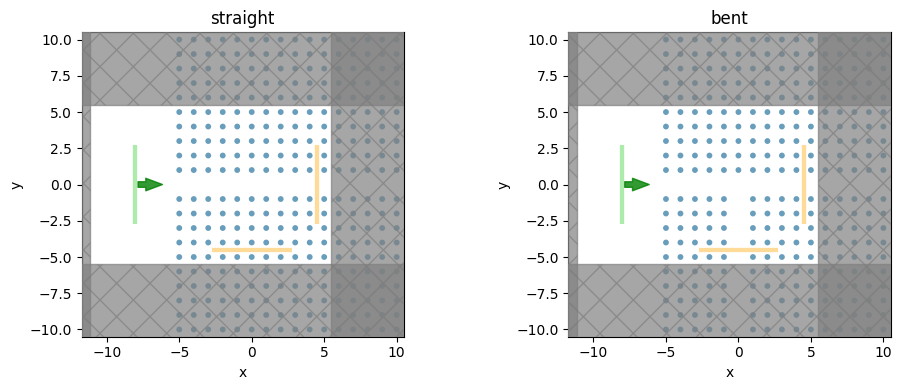

In [13]:
_, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
_ = sim_straight.plot(z=0.01, ax=ax1)
_ = sim_bent.plot(z=0.01, ax=ax2)
ax1.set_title('straight')
ax2.set_title('bent')

plt.show()

In [14]:
sims0 = dict(straight=sim_straight, bent=sim_bent)
batch0 = web.Batch(simulations=sims0)
batch_data0 = batch0.run(path_dir='data')

Output()

12:47:15 EDT Started working on Batch containing 2 tasks.

12:47:19 EDT Maximum FlexCredit cost: 0.050 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

12:47:47 EDT Batch complete.

Output()

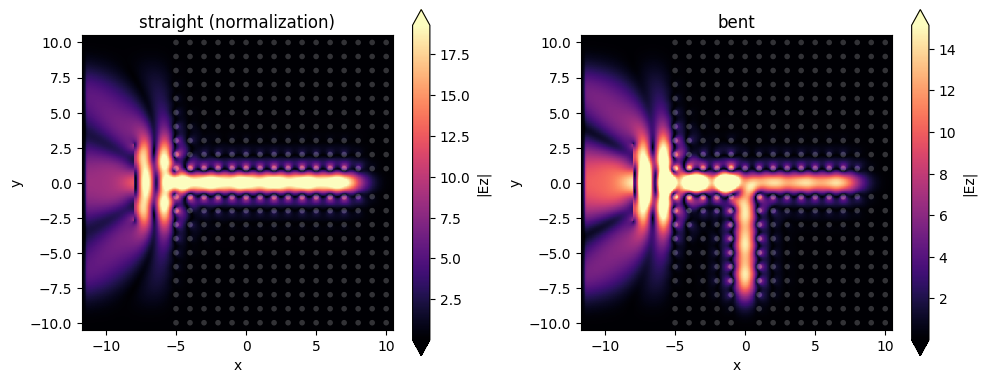

In [15]:
_, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
f = freq0
_ = batch_data0['straight'].plot_field("field", field_name="Ez", val="abs", f=freq0, ax=ax1)
_ = batch_data0['bent'].plot_field("field", field_name="Ez", val="abs", f=freq0, ax=ax2)
ax1.set_title('straight (normalization)')
ax2.set_title('bent')

plt.show()

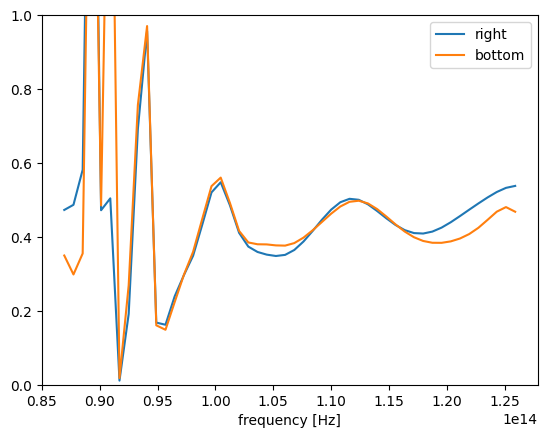

In [16]:
flux0_norm = abs(batch_data0['straight']['flux_x'].flux)
flux_straight = float(flux0_norm.interp(f=freq0).values)

flux0_bent_x = abs(batch_data0['bent']['flux_x'].flux)
flux0_bent_y = abs(batch_data0['bent']['flux_y'].flux)

flux0_x = flux0_bent_x / flux_straight
flux0_y = flux0_bent_y / flux_straight

flux0_x.plot(x='f', label='right')
flux0_y.plot(x='f', label='bottom')

plt.ylim([0,1])
plt.legend()
plt.show()

In [17]:
from autograd.tracer import getval

def objective(params):

    sim = make_sim(params, is_bent=True, optimization_mode=True)
    sim_data = web.run(sim, task_name='phc_adjoint', verbose=False)
    
    flux_x = abs(anp.sum(sim_data['flux_x'].flux.values)) / flux_straight
    flux_y = abs(anp.sum(sim_data['flux_y'].flux.values)) / flux_straight

    # in the ideal case: flux_y = 1, flux_x = 0 -> objective = 1
    # in the worst case: flux_y = 0, flux_x = 1 -> objective = -1
    return flux_y - flux_x
    
val_grad = autograd.value_and_grad(objective)

In [ ]:
import optax
from autograd.tracer import getval

# hyperparameters
num_steps = 20
learning_rate = 0.03

# initialize adam optimizer with starting parameters
params = np.array(params0).copy()
optimizer = optax.adam(learning_rate=learning_rate)
opt_state = optimizer.init(params)

# store history
objective_history = []
param_history = [params]
data_history = []

In [25]:
for i in range(num_steps):
    # compute gradient and current objective funciton value
    value, gradient = val_grad(params)

    # multiply all by -1 to maximize obj_fn
    gradient = np.array(gradient)

    # outputs
    print(f"step = {i + 1 + num_steps}")
    print(f"\tJ = {value:.4e}")
    print(f"\tgrad_norm = {np.linalg.norm(gradient):.4e}")

    # compute and apply updates to the optimizer based on gradient
    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params = optax.apply_updates(params, updates)

    # it is important using optax to convert the parameters back to numpy arrays to feed back to our gradient
    params = np.array(params)

    # save history
    objective_history.append(value)
    param_history.append(params)

step = 21
	J = 4.4486e-01
	grad_norm = 4.0644e-01
step = 22
	J = 4.0715e-01
	grad_norm = 4.2329e-01


KeyboardInterrupt: 

In [ ]:
plt.plot(objective_history)
plt.xlabel('iteration')
plt.ylabel('objective function')

In [ ]:
params_last = param_history[-1]

sim = make_sim(params_last, is_bent=True, optimization_mode=False)
_ = sim.plot(z=0.01)
plt.show()

In [21]:
sim_data = web.run(sim, task_name='phc')

13:19:40 EDT Created task 'phc' with task_id                                    
             'fdve-a8a931ad-af1b-4664-8774-aad940d5cee6' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=188618;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=989123;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\taskId]8;;\]8;id=188618;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\=]8;;\]8;id=826423;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\fdve]8;;\]8;id=188618;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\-a8a931ad-af1]8;;\
             ]8;id=188618;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\b-4664-8774-aad940d5cee6']8;;\.

Output()

13:19:42 EDT status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

Output()

13:20:04 EDT status = success

             View simulation result at                                          
             ]8;id=743575;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=227356;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\taskId]8;;\]8;id=743575;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\=]8;;\]8;id=477363;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\fdve]8;;\]8;id=743575;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\-a8a931ad-af1]8;;\
             ]8;id=743575;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a8a931ad-af1b-4664-8774-aad940d5cee6\b-4664-8774-aad940d5cee6']8;;\.

Output()

13:20:08 EDT loading simulation from simulation_data.hdf5

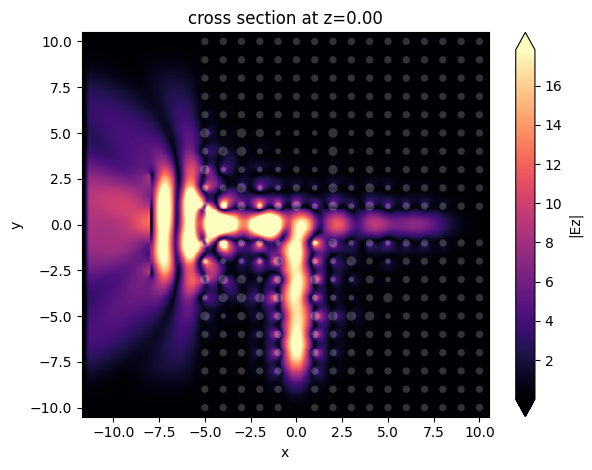

In [22]:
ax = sim_data.plot_field("field", field_name="Ez", val="abs", f=freq0)
plt.show()

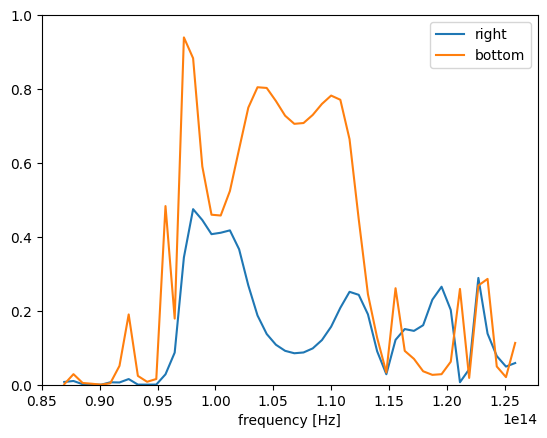

In [23]:
flux0_bent_x = abs(sim_data['flux_x'].flux)
flux0_bent_y = abs(sim_data['flux_y'].flux)

flux0_x = flux0_bent_x / flux_straight
flux0_y = flux0_bent_y / flux_straight

flux0_x.plot(x='f', label='right')
flux0_y.plot(x='f', label='bottom')

plt.ylim([0,1])
plt.legend()
plt.show()